In [1]:
pip install numpy matplotlib

  Using cached numpy-2.3.4-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp311-cp311-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached numpy-2.3.4-cp311-cp311-win_amd64.whl (13.1 MB)
Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
Using cached pillow-12.0.0-cp311-cp311-win_amd64.wh

In [9]:
# --------------------------------------------------------------
# 1. Load libraries
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [10]:
# --------------------------------------------------------------
# 2. Load the .npz file (all splits are inside)
# --------------------------------------------------------------
data = np.load('pneumoniamnist.npz', allow_pickle=True)

# MedMNIST v2 menyimpan data dalam bentuk:
#   train_images, train_labels
#   val_images,   val_labels
#   test_images,  test_labels
train_img = data['train_images']
train_lbl = data['train_labels'].ravel()
val_img   = data['val_images']
val_lbl   = data['val_labels'].ravel()
test_img  = data['test_images']
test_lbl  = data['test_labels'].ravel()

In [11]:
# --------------------------------------------------------------
# 3. Gabungkan SEMUA gambar & label menjadi satu dataset
# --------------------------------------------------------------
all_images = np.concatenate([train_img, val_img, test_img], axis=0)
all_labels = np.concatenate([train_lbl, val_lbl, test_lbl], axis=0)

print(f"Total samples : {all_images.shape[0]}")
print(f"Image shape   : {all_images.shape[1:]}")   # (28, 28)

Total samples : 5856
Image shape   : (28, 28)



=== CLASS DISTRIBUTION (ALL DATA) ===
Class 0 (Normal): 1583 samples (0.2703 | 27.03%)
Class 1 (Pneumonia): 4273 samples (0.7297 | 72.97%)


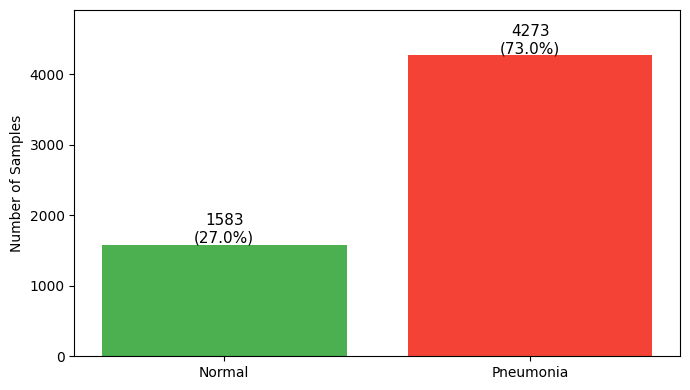

In [15]:
# --------------------------------------------------------------
# 4. Distribusi kelas & proporsi
# --------------------------------------------------------------
label_names = ['Normal', 'Pneumonia']          # 0 = Normal, 1 = Pneumonia
class_counts = Counter(all_labels)
total = len(all_labels)

print("\n=== CLASS DISTRIBUTION (ALL DATA) ===")
for lbl, cnt in sorted(class_counts.items()):
    prop = cnt / total
    print(f"Class {lbl} ({label_names[lbl]}): {cnt:4d} samples "
          f"({prop:.4f} | {prop*100:5.2f}%)")

# Visualisasi distribusi
plt.figure(figsize=(7, 4))
bars = plt.bar(label_names,
               [class_counts[i] for i in range(len(label_names))],
               color=['#4CAF50', '#F44336'])
# plt.title('Class Distribution – PneumoniaMNIST v2 (All Data)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 30,
             f'{int(yval)}\n({yval/total*100:.1f}%)',
             ha='center', fontsize=11)
plt.ylim(0, max(class_counts.values())*1.15)
plt.tight_layout()
plt.show()

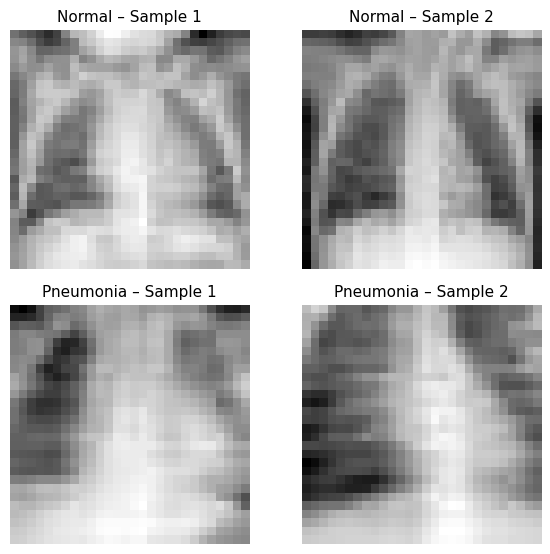

In [14]:
# --------------------------------------------------------------
# 5. Tampilkan 2 contoh gambar per kelas
# --------------------------------------------------------------
unique_classes = np.unique(all_labels)      # [0, 1]
n_samples_per_class = 2

fig, axes = plt.subplots(nrows=len(unique_classes),
                         ncols=n_samples_per_class,
                         figsize=(3*n_samples_per_class, 3*len(unique_classes)))
# fig.suptitle('Sample Images per Class (All Data)', fontsize=15, fontweight='bold')

for row, cls in enumerate(unique_classes):
    # Ambil indeks acak dari kelas tersebut
    idx_class = np.where(all_labels == cls)[0]
    np.random.seed(42)                     # reproducibility
    chosen = np.random.choice(idx_class, n_samples_per_class, replace=False)

    for col in range(n_samples_per_class):
        ax = axes[row, col] if len(unique_classes) > 1 else axes[col]
        ax.imshow(all_images[chosen[col]], cmap='gray')
        ax.set_title(f'{label_names[cls]} – Sample {col+1}', fontsize=11)
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [17]:
pip install pandas scipy

  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl (11.3 MB)
Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl (38.7 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [scipy]
   -------------------- ---------------

In [57]:
# --------------------------------------------------------------
# 6. Bagi dataset menjadi 3 CLIENT HETEROGEN (Dirichlet + LogNormal Size)
#    → PASTIKAN SETIAP CLIENT PUNYA KEDUA KELAS (min 5% per kelas)
# --------------------------------------------------------------
import scipy.stats as stats
import numpy as np
from collections import Counter

np.random.seed(42)

# === FORMULA & RULES UNTUK HETEROGENITAS (3 CLIENT) ===
alpha_dirichlet = 0.3        # non-IID kuat
mu_size, sigma_size = 7.0, 0.5  # lognormal untuk ukuran client

# Ukuran client via lognormal
client_sizes_raw = np.random.lognormal(mu_size, sigma_size, 3)
client_sizes = np.round(client_sizes_raw / client_sizes_raw.sum() * len(all_images)).astype(int)

# Koreksi: minimal 300 sampel per client
client_sizes = np.clip(client_sizes, 300, None)
diff = len(all_images) - client_sizes.sum()
if diff > 0:
    client_sizes[np.argsort(client_sizes)[:diff]] += 1
elif diff < 0:
    client_sizes[np.argsort(-client_sizes)[:abs(diff)]] -= 1

# === Dirichlet proporsi kelas (2 kelas), clip 5%-95% ===
min_prop = 0.05
max_prop = 0.95

raw_props = np.random.dirichlet([alpha_dirichlet] * 3, size=2)  # (2, 3)
raw_props = np.clip(raw_props, min_prop, max_prop)
raw_props = raw_props / raw_props.sum(axis=0, keepdims=True)

# Target jumlah per kelas
target_counts = np.zeros((3, 2), dtype=int)
for i in range(3):
    n_normal = max(1, int(raw_props[0, i] * client_sizes[i]))
    n_pneumo = client_sizes[i] - n_normal
    target_counts[i, 0] = n_normal
    target_counts[i, 1] = n_pneumo

# === Alokasi data ===
idx_normal = np.where(all_labels == 0)[0]
idx_pneumo = np.where(all_labels == 1)[0]

np.random.shuffle(idx_normal)
np.random.shuffle(idx_pneumo)

ptr_n = ptr_p = 0
client_indices = []

for i in range(3):
    n_need = target_counts[i, 0]
    p_need = target_counts[i, 1]
    
    take_n = idx_normal[ptr_n : ptr_n + n_need]
    take_p = idx_pneumo[ptr_p : ptr_p + p_need]
    
    client_idx = np.concatenate([take_n, take_p])
    client_indices.append(client_idx)
    
    ptr_n += n_need
    ptr_p += p_need

# Sisa data → distribusi merata
remaining_n = idx_normal[ptr_n:]
remaining_p = idx_pneumo[ptr_p:]

for i in range(3):
    add_n = len(remaining_n) // 3 + (1 if i < len(remaining_n) % 3 else 0)
    add_p = len(remaining_p) // 3 + (1 if i < len(remaining_p) % 3 else 0)
    if add_n > 0 and len(remaining_n) >= add_n:
        client_indices[i] = np.concatenate([client_indices[i], remaining_n[:add_n]])
        remaining_n = remaining_n[add_n:]
    if add_p > 0 and len(remaining_p) >= add_p:
        client_indices[i] = np.concatenate([client_indices[i], remaining_p[:add_p]])
        remaining_p = remaining_p[add_p:]

# Simpan ke client_1, client_2, client_3
client_1 = {'images': all_images[client_indices[0]], 'labels': all_labels[client_indices[0]]}
client_2 = {'images': all_images[client_indices[1]], 'labels': all_labels[client_indices[1]]}
client_3 = {'images': all_images[client_indices[2]], 'labels': all_labels[client_indices[2]]}

In [58]:
# --------------------------------------------------------------
# 7. Tampilkan distribusi per client
# --------------------------------------------------------------
print("\n" + "="*70)
print("3 CLIENT HETEROGEN (Dirichlet α=0.3 + LogNormal Size + Min 5% per Class)")
print("="*70)

clients = [client_1, client_2, client_3]
for i, client in enumerate(clients, 1):
    labels = client['labels']
    total = len(labels)
    normal = np.sum(labels == 0)
    pneumo = np.sum(labels == 1)
    print(f"client_{i} | N={total:4d} | Normal={normal:4d} ({normal/total:.3f}) | "
          f"Pneumonia={pneumo:4d} ({pneumo/total:.3f})")
    assert normal > 0 and pneumo > 0, f"client_{i} harus punya kedua kelas!"


3 CLIENT HETEROGEN (Dirichlet α=0.3 + LogNormal Size + Min 5% per Class)
client_1 | N=2645 | Normal=1043 (0.394) | Pneumonia=1602 (0.606)
client_2 | N=1890 | Normal=  75 (0.040) | Pneumonia=1815 (0.960)
client_3 | N= 825 | Normal= 465 (0.564) | Pneumonia= 360 (0.436)


In [59]:
# --------------------------------------------------------------
# 8. Uji Statistik: Chi-Square untuk Heterogenitas Label
# --------------------------------------------------------------
print("\n" + "-"*70)
print("UJI CHI-SQUARE: Homogeneity of Class Distributions")
print("-"*70)

contingency = np.array([
    [np.sum(c['labels'] == 0), np.sum(c['labels'] == 1)] for c in clients
])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic : {chi2:.2f}")
print(f"p-value              : {p_chi2:.2e}")
print(f"Degrees of freedom   : {dof}")
print(f"Reject H0 (p < 0.05) : {'YES' if p_chi2 < 0.05 else 'NO'}")
print("→ Distribusi kelas antar client BERBEDA SECARA SIGNIFIKAN." if p_chi2 < 0.05 else "→ Tidak cukup bukti.")


----------------------------------------------------------------------
UJI CHI-SQUARE: Homogeneity of Class Distributions
----------------------------------------------------------------------
Chi-square statistic : 1003.47
p-value              : 1.25e-218
Degrees of freedom   : 2
Reject H0 (p < 0.05) : YES
→ Distribusi kelas antar client BERBEDA SECARA SIGNIFIKAN.


In [60]:
# --------------------------------------------------------------
# 9. Uji KS pada Mean Pixel Intensity
# --------------------------------------------------------------
print("\n" + "-"*70)
print("UJI KOLMOGOROV-SMIRNOV: Distribusi Intensitas Rata-rata")
print("-"*70)

mean_intensities = [np.mean(c['images'], axis=(1,2)) for c in clients]
sig_count = 0
total_pairs = 0
for i in range(3):
    for j in range(i+1, 3):
        total_pairs += 1
        ks_stat, p_ks = stats.ks_2samp(mean_intensities[i], mean_intensities[j])
        if p_ks < 0.05:
            sig_count += 1
            print(f"client_{i+1} vs client_{j+1}: p = {p_ks:.2e} → BERBEDA")

print(f"\nPasangan signifikan (p<0.05): {sig_count}/{total_pairs}")


----------------------------------------------------------------------
UJI KOLMOGOROV-SMIRNOV: Distribusi Intensitas Rata-rata
----------------------------------------------------------------------
client_1 vs client_2: p = 4.68e-12 → BERBEDA
client_1 vs client_3: p = 2.03e-02 → BERBEDA
client_2 vs client_3: p = 9.10e-14 → BERBEDA

Pasangan signifikan (p<0.05): 3/3


In [29]:
pip install torch torchvision torchaudio scikit-learn numpy matplotlib seaborn

  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   ---------------------------------------- 0.8/109.3 MB 4.8 MB/s eta 0:00:23
    --------------------------------------- 1.8/109.3 MB 4.6 MB/s eta 0:00:24
    --------------------------------------- 2.6/109.3 MB 4.3 MB/s eta 0:00:25
   - -------------------------------------- 3.7/109.3 MB 4.4 MB/s eta 0:00:24
   - -------------------------------------- 5.2/109.3 MB 4.9 MB/s eta 

In [86]:
# --------------------------------------------------------------
# 10. FULL FEDERATED LEARNING PIPELINE (FIXED + FINAL VISUALIZATION)
#     - 5-Fold CV per Client (No Merging)
#     - 50 Rounds
#     - 4 FL Algorithms + Local
#     - Print: Rapi, vertikal
#     - Average 5 folds → Same print format
#     - PR Curve, ROC Curve, Confusion Matrix (normalized)
# --------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, precision_recall_curve, roc_curve, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings("ignore")

# Seed
torch.manual_seed(42)
np.random.seed(42)

In [88]:
# --------------------------------------------------------------
# 10.1 CNN Ringan
# --------------------------------------------------------------
class LightweightCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.25)
    
    def forward(self, x):
        x = x.unsqueeze(1).float() / 255.0
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Model
model = LightweightCNN()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

LightweightCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Total parameters: 105,281


In [ ]:
# --------------------------------------------------------------
# 10.2 Evaluation & Metrics
# --------------------------------------------------------------
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            out = model(Xb)
            prob = torch.sigmoid(out).cpu().numpy().flatten()
            pred = (prob > 0.5).astype(int)
            y_true.extend(yb.cpu().numpy().flatten())
            y_pred.extend(pred)
            y_prob.extend(prob)
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5
    try:
        logloss = log_loss(y_true, y_prob, labels=[0, 1])
    except:
        logloss = 0.693
    return {
        'akurasi': acc, 'presisi': prec, 'recall': rec,
        'f1_score': f1, 'roc_auc': auc, 'log_loss': logloss
    }

def train_local(model, loader, epochs=1, lr=0.01):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
    return model

In [91]:
# --------------------------------------------------------------
# 10.3 5-Fold CV + 4 Global Models
# --------------------------------------------------------------
clients = [client_1, client_2, client_3]
K = len(clients)
fold_results = {name: [] for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']}

# Store for curves (last round)
all_y_true = {name: [] for name in fold_results}
all_y_prob = {name: [] for name in fold_results}

for fold in range(5):
    print(f"\n{'='*70}")
    print(f"{' '*25} FOLD {fold+1}/5")
    print(f"{'='*70}")
    
    # Split per client
    train_loaders, test_loaders, client_sizes = [], [], []
    for client in clients:
        X, y = client['images'], client['labels']
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + fold)
        for train_idx, test_idx in skf.split(X, y):
            X_train = torch.tensor(X[train_idx])
            y_train = torch.tensor(y[train_idx]).float().unsqueeze(1)
            X_test = torch.tensor(X[test_idx])
            y_test = torch.tensor(y[test_idx]).float().unsqueeze(1)
            train_loaders.append(DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True))
            test_loaders.append(DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False))
            client_sizes.append(len(train_idx))
            break
    total_n = sum(client_sizes)
    
    # Global models
    global_models = {name: copy.deepcopy(model) for name in ['fedavg', 'fedprox', 'fedsvrg', 'fedatt']}
    
    # Control variates (list of tensors)
    params = list(model.parameters())
    c_global = {name: [torch.zeros_like(p) for p in params] for name in ['fedsvrg']}
    c_local = [[torch.zeros_like(p) for p in params] for _ in range(K)]
    
    round_metrics = {name: [] for name in fold_results}
    
    for round_num in range(1, 51):
        # Local training
        local_models = [train_local(copy.deepcopy(model), loader, epochs=1) for loader in train_loaders]
        local_params = [list(m.parameters()) for m in local_models]
        
        # LOCAL EVAL
        local_scores = []
        for i, loader in enumerate(test_loaders):
            yt, yp, ypr = evaluate_model(local_models[i], loader)
            local_scores.append(compute_metrics(yt, yp, ypr))
        local_avg = {k: np.mean([m[k] for m in local_scores]) for k in local_scores[0]}
        round_metrics['local'].append(local_avg)
        
        # 1. FedAvg
        w_avg = copy.deepcopy(global_models['fedavg'])
        for p in w_avg.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = client_sizes[i] / total_n
            for pg, pl in zip(w_avg.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedavg'] = w_avg
        
        # 2. FedProx
        w_prox = copy.deepcopy(global_models['fedprox'])
        for i, loader in enumerate(train_loaders):
            m = copy.deepcopy(w_prox)
            opt = optim.Adam(m.parameters(), lr=0.01)
            crit = nn.BCEWithLogitsLoss()
            for _ in range(3):
                for Xb, yb in loader:
                    opt.zero_grad()
                    out = m(Xb)
                    loss = crit(out, yb)
                    prox = 0.01/2 * sum((p-q).norm(2)**2 for p, q in zip(m.parameters(), w_prox.parameters()))
                    (loss + prox).backward()
                    opt.step()
            local_models[i] = m
        for p in w_prox.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = client_sizes[i] / total_n
            for pg, pl in zip(w_prox.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedprox'] = w_prox
        
        # 3. FedSVRG (SCAFFOLD)
        w_svrg = copy.deepcopy(global_models['fedsvrg'])
        w_params = list(w_svrg.parameters())
        for i, loader in enumerate(train_loaders):
            m = copy.deepcopy(w_svrg)
            m_params = list(m.parameters())
            opt = optim.Adam(m.parameters(), lr=0.01)
            crit = nn.BCEWithLogitsLoss()
            for _ in range(3):
                for Xb, yb in loader:
                    opt.zero_grad()
                    out = m(Xb)
                    loss = crit(out, yb)
                    loss.backward()
                    # Apply control variate
                    for j, (p, c_k, c_g) in enumerate(zip(m_params, c_local[i], c_global['fedsvrg'])):
                        if p.grad is not None:
                            p.grad = p.grad - c_k + c_g
                    opt.step()
            local_models[i] = m
            local_params[i] = m_params
        
        # Update control variates
        for j in range(len(w_params)):
            delta = sum((local_params[i][j] - w_params[j]) for i in range(K)) / K
            c_global['fedsvrg'][j] += delta
            for i in range(K):
                c_local[i][j] = c_global['fedsvrg'][j]
        
        # Aggregation
        for p in w_svrg.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = 1.0 / K
            for pg, pl in zip(w_svrg.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedsvrg'] = w_svrg
        
        # 4. FedAtt
        w_att = copy.deepcopy(global_models['fedatt'])
        sims = []
        for m in local_models:
            sim = sum(F.cosine_similarity(pg.flatten(), pl.flatten(), dim=0)
                      for pg, pl in zip(w_att.parameters(), m.parameters()))
            sims.append(sim.item())
        attn = F.softmax(torch.tensor(sims), dim=0)
        for p in w_att.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            for pg, pl in zip(w_att.parameters(), m.parameters()):
                pg.data += attn[i] * pl.data
        global_models['fedatt'] = w_att
        
        # GLOBAL EVAL
        for name in ['fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
            gmodel = global_models[name]
            scores = []
            y_true_all, y_prob_all = [], []
            for loader in test_loaders:
                yt, yp, ypr = evaluate_model(gmodel, loader)
                scores.append(compute_metrics(yt, yp, ypr))
                y_true_all.extend(yt)
                y_prob_all.extend(ypr)
            avg = {k: np.mean([m[k] for m in scores]) for k in scores[0]}
            round_metrics[name].append(avg)
            if round_num == 50:  # Save for final curves
                all_y_true[name].append(np.array(y_true_all))
                all_y_prob[name].append(np.array(y_prob_all))
        
        # Save local for curves
        if round_num == 50:
            yt_all, yp_all, ypr_all = [], [], []
            for i, loader in enumerate(test_loaders):
                yt, yp, ypr = evaluate_model(local_models[i], loader)
                yt_all.extend(yt); ypr_all.extend(ypr)
            all_y_true['local'].append(np.array(yt_all))
            all_y_prob['local'].append(np.array(ypr_all))
        
        # PRINT
        print(f"\n--- Round {round_num} ---")
        for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
            m = round_metrics[name][-1]
            print(f"{name.upper()} round {round_num}")
            print(f"  akurasi : {m['akurasi']:.4f}")
            print(f"  presisi : {m['presisi']:.4f}")
            print(f"  recall  : {m['recall']:.4f}")
            print(f"  f1_score: {m['f1_score']:.4f}")
            print(f"  roc_auc : {m['roc_auc']:.4f}")
            print(f"  log_loss: {m['log_loss']:.4f}")
    
    for name in round_metrics:
        fold_results[name].append(round_metrics[name])


                          FOLD 1/5

--- Round 1 ---
LOCAL round 1
  akurasi : 0.7096
  presisi : 0.5217
  recall  : 0.6667
  f1_score: 0.5779
  roc_auc : 0.6913
  log_loss: 0.5005
FEDAVG round 1
  akurasi : 0.6672
  presisi : 0.6672
  recall  : 1.0000
  f1_score: 0.7804
  roc_auc : 0.7714
  log_loss: 0.6621
FEDPROX round 1
  akurasi : 0.6691
  presisi : 0.6683
  recall  : 1.0000
  f1_score: 0.7813
  roc_auc : 0.9465
  log_loss: 0.5532
FEDSVRG round 1
  akurasi : 0.6672
  presisi : 0.6672
  recall  : 1.0000
  f1_score: 0.7804
  roc_auc : 0.9526
  log_loss: 0.6540
FEDATT round 1
  akurasi : 0.8541
  presisi : 0.9030
  recall  : 0.8667
  f1_score: 0.8820
  roc_auc : 0.9463
  log_loss: 0.5389

--- Round 2 ---
LOCAL round 2
  akurasi : 0.7972
  presisi : 0.6422
  recall  : 0.6031
  f1_score: 0.6202
  roc_auc : 0.8447
  log_loss: 0.3919
FEDAVG round 2
  akurasi : 0.6672
  presisi : 0.6672
  recall  : 1.0000
  f1_score: 0.7804
  roc_auc : 0.6494
  log_loss: 0.6554
FEDPROX round 2
  akurasi :


                          AVERAGE OF 5 FOLDS

--- Round 1 ---
LOCAL round 1
  Accuracy : 0.7462
  Precision: 0.5538
  Recall   : 0.6594
  F1-Score : 0.5968
  ROC-AUC  : 0.7509
  Log-Loss : 0.4550
FEDAVG round 1
  Accuracy : 0.6672
  Precision: 0.6672
  Recall   : 1.0000
  F1-Score : 0.7804
  ROC-AUC  : 0.7726
  Log-Loss : 0.6541
FEDPROX round 1
  Accuracy : 0.7170
  Precision: 0.7018
  Recall   : 0.9994
  F1-Score : 0.8071
  ROC-AUC  : 0.9600
  Log-Loss : 0.5623
FEDSVRG round 1
  Accuracy : 0.6724
  Precision: 0.6703
  Recall   : 0.9998
  F1-Score : 0.7828
  ROC-AUC  : 0.8219
  Log-Loss : 0.6523
FEDATT round 1
  Accuracy : 0.7482
  Precision: 0.8257
  Recall   : 0.8511
  F1-Score : 0.8037
  ROC-AUC  : 0.8576
  Log-Loss : 0.5575

--- Round 2 ---
LOCAL round 2
  Accuracy : 0.7873
  Precision: 0.6171
  Recall   : 0.6177
  F1-Score : 0.6134
  ROC-AUC  : 0.7824
  Log-Loss : 0.4046
FEDAVG round 2
  Accuracy : 0.6684
  Precision: 0.6678
  Recall   : 1.0000
  F1-Score : 0.7809
  ROC-AUC  : 0.

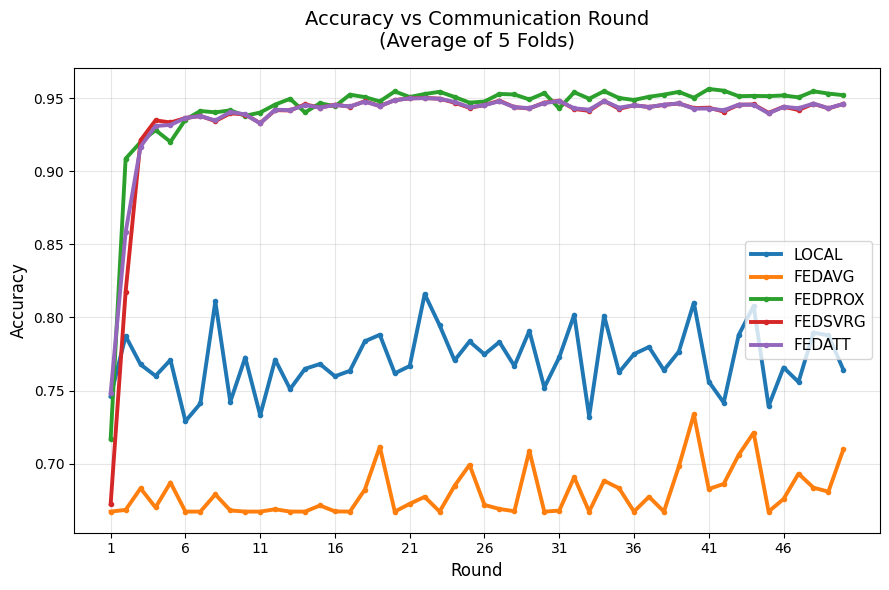

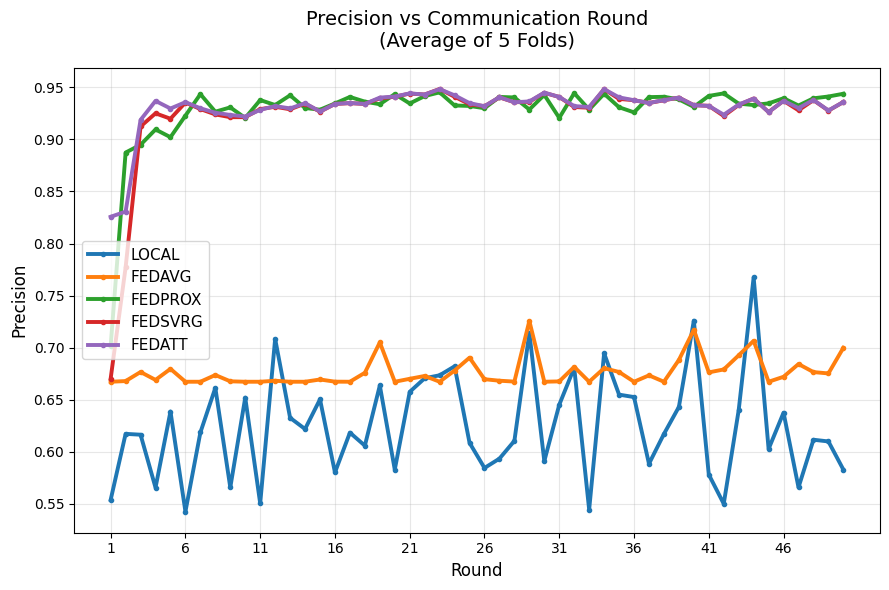

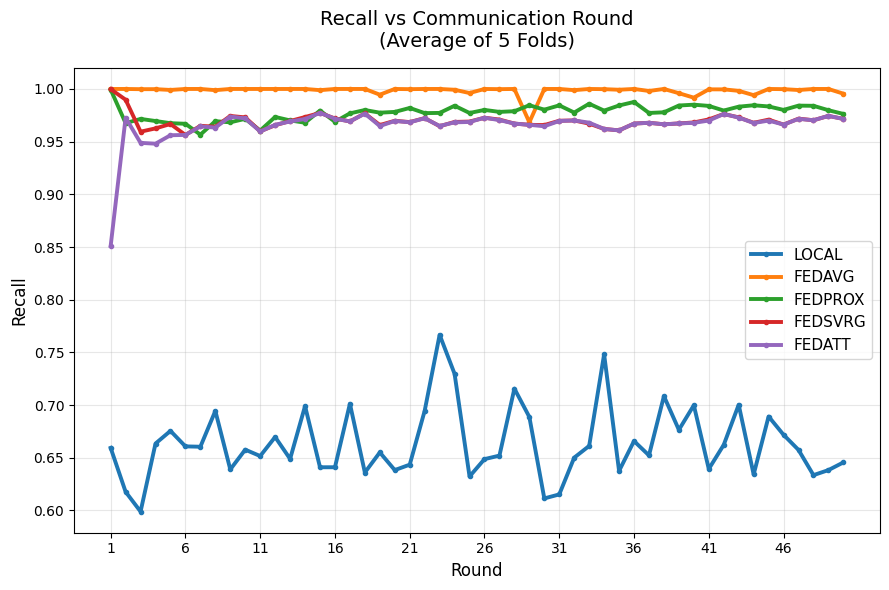

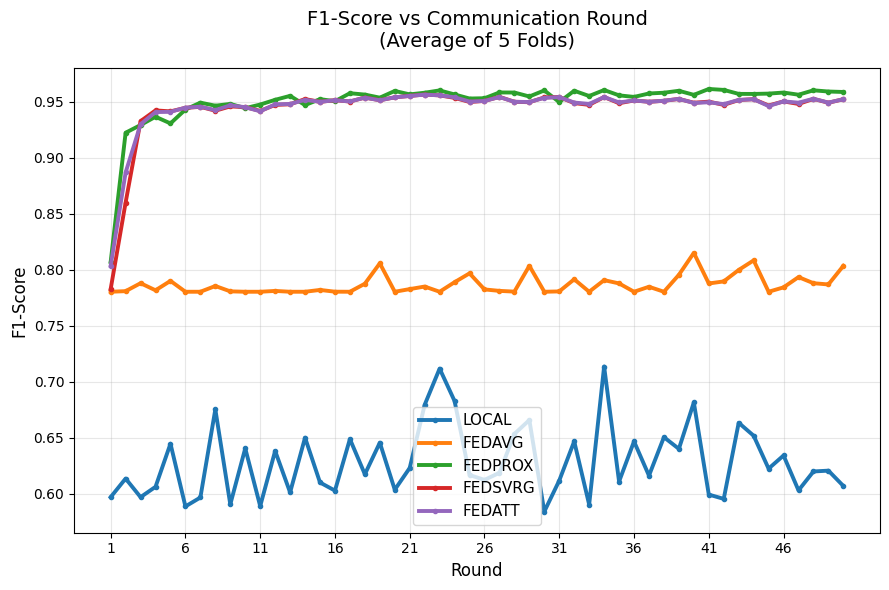

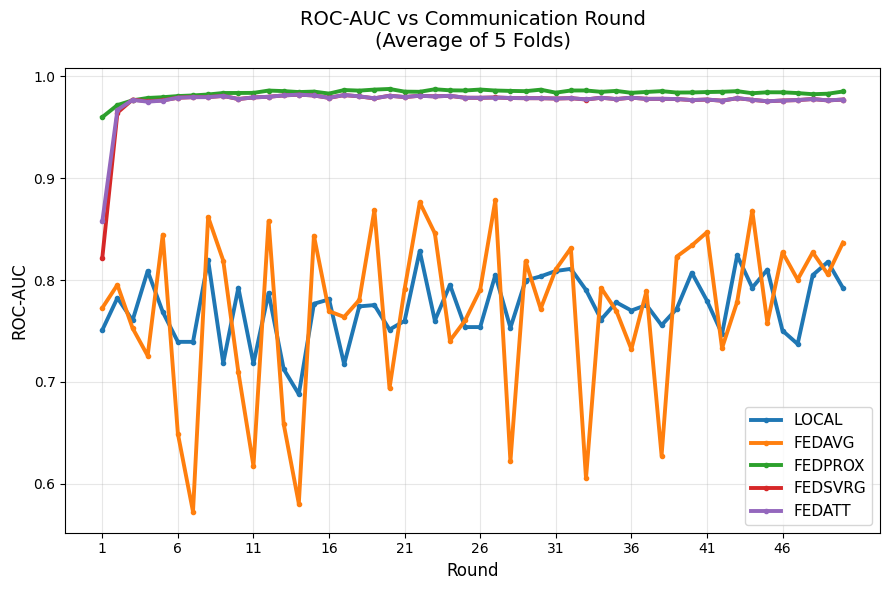

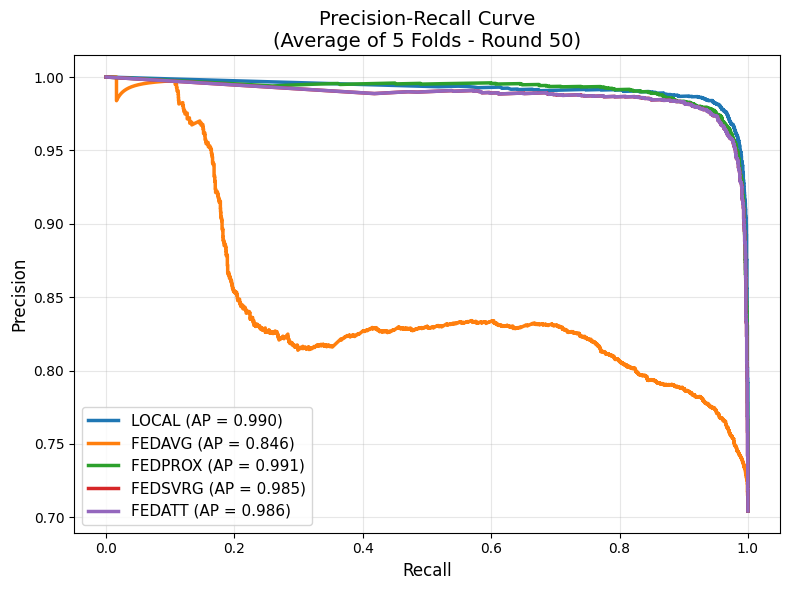

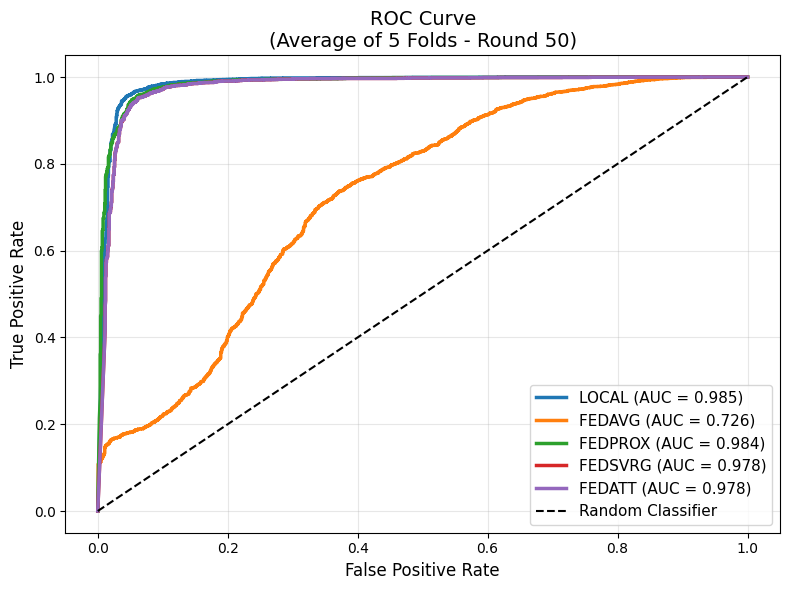

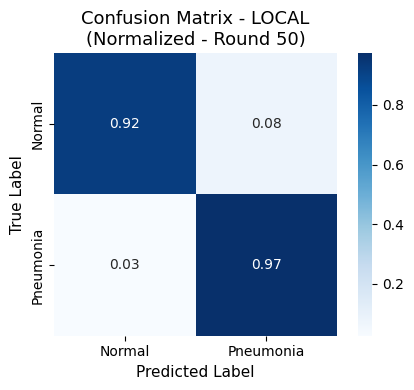

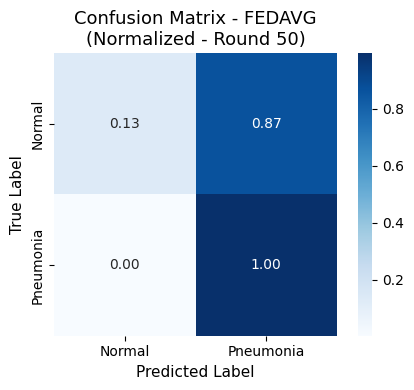

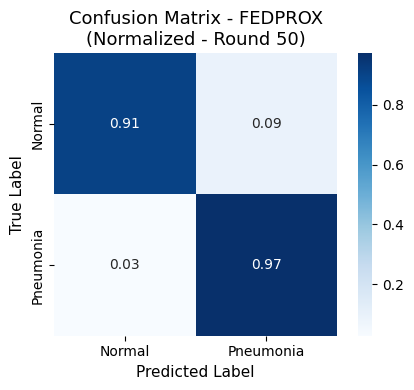

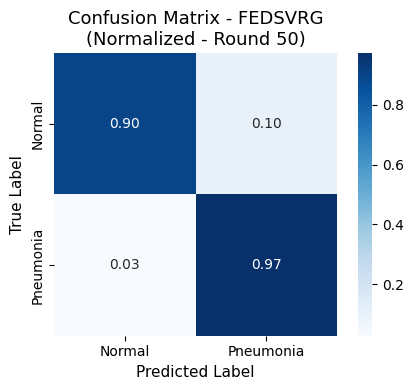

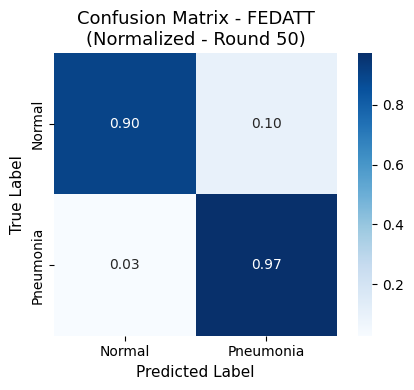


FINAL PERFORMANCE (Round 50 - Average of 5 Folds)
Model         Accuracy  Precision   Recall       F1      AUC     Loss
----------------------------------------------------------------------------------------------------
LOCAL        0.7642    0.5828     0.6456   0.6068   0.7921   0.4267
FEDAVG       0.7097    0.6998     0.9955   0.8035   0.8367   0.6130
FEDPROX      0.9521    0.9439     0.9763   0.9589   0.9852   0.1850
FEDSVRG      0.9461    0.9360     0.9716   0.9525   0.9772   0.2687
FEDATT       0.9461    0.9360     0.9716   0.9525   0.9773   0.2687


In [95]:
# --------------------------------------------------------------
# 11. AGGREGATION OF 5 FOLDS + FINAL VISUALIZATION (REVISED)
#     - Separate figures (1 image per plot)
#     - All in English
#     - Line plots: 1 metric per figure
#     - PR Curve: 1 figure
#     - ROC Curve: 1 figure
#     - Confusion Matrix: 5 separate figures
# --------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, confusion_matrix
import seaborn as sns

# === 1. Aggregate 5 Folds ===
avg_round = {name: [] for name in fold_results}
for name in fold_results:
    for r in range(50):
        round_data = [fold_results[name][f][r] for f in range(5)]
        avg = {k: np.mean([m[k] for m in round_data]) for k in round_data[0]}
        avg_round[name].append(avg)

# === 2. PRINT AVERAGE 5 FOLDS (ENGLISH) ===
print(f"\n{'='*70}")
print(f"{' '*25} AVERAGE OF 5 FOLDS")
print(f"{'='*70}")
for round_num in range(1, 51):
    print(f"\n--- Round {round_num} ---")
    for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
        m = avg_round[name][round_num-1]
        print(f"{name.upper()} round {round_num}")
        print(f"  Accuracy : {m['akurasi']:.4f}")
        print(f"  Precision: {m['presisi']:.4f}")
        print(f"  Recall   : {m['recall']:.4f}")
        print(f"  F1-Score : {m['f1_score']:.4f}")
        print(f"  ROC-AUC  : {m['roc_auc']:.4f}")
        print(f"  Log-Loss : {m['log_loss']:.4f}")

# === 3. LINE PLOTS: 1 METRIC PER FIGURE ===
metrics = ['akurasi', 'presisi', 'recall', 'f1_score', 'roc_auc', 'log_loss']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Log-Loss']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for met, title, color in zip(metrics, titles, colors):
    plt.figure(figsize=(9, 6))
    for i, algo in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
        vals = [r[met] for r in avg_round[algo]]
        plt.plot(range(1, 51), vals, label=algo.upper(), linewidth=2.8, color=colors[i], marker='o', markersize=3)
    plt.title(f'{title} vs Communication Round\n(Average of 5 Folds)', fontsize=14, pad=15)
    plt.xlabel('Round', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 51, 5))
    plt.tight_layout()
    plt.show()

from sklearn.metrics import average_precision_score

# === 4. PRECISION-RECALL CURVE (WITH AP SCORE) ===
plt.figure(figsize=(8, 6))
for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)  # AP Score
    plt.plot(rec, prec, label=f"{name.upper()} (AP = {ap:.3f})", linewidth=2.5, color=colors[i])
plt.title('Precision-Recall Curve\n(Average of 5 Folds - Round 50)', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 5. ROC CURVE (WITH AUC SCORE) ===
plt.figure(figsize=(8, 6))
for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name.upper()} (AUC = {auc:.3f})", linewidth=2.5, color=colors[i])
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.title('ROC Curve\n(Average of 5 Folds - Round 50)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 6. CONFUSION MATRIX: 5 SEPARATE FIGURES ===
model_names = ['LOCAL', 'FEDAVG', 'FEDPROX', 'FEDSVRG', 'FEDATT']

for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    y_pred = (y_prob > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'],
                cbar=True, square=True)
    plt.title(f'Confusion Matrix - {model_names[i]}\n(Normalized - Round 50)', fontsize=13)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.show()

# === 7. FINAL PERFORMANCE TABLE ===
print("\n" + "="*100)
print("FINAL PERFORMANCE (Round 50 - Average of 5 Folds)")
print("="*100)
print(f"{'Model':<12} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'Loss':>8}")
print("-"*100)
for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
    r = avg_round[name][-1]
    print(f"{name.upper():<12} {r['akurasi']:.4f}    {r['presisi']:.4f}     {r['recall']:.4f}   {r['f1_score']:.4f}   {r['roc_auc']:.4f}   {r['log_loss']:.4f}")